# Grundlagen der Künstlichen Intelligenz.
# Exercise 4. Genetic Algorithms

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 4 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

## Problem Setup

### City Coordinates

- Create a set of 10 cities with random `(x, y)` coordinates.
- Represent these coordinates as a dictionary or a list of tuples.

City 0: (37.454011884736246, 95.07143064099162)
City 1: (73.1993941811405, 59.86584841970366)
City 2: (15.601864044243651, 15.599452033620265)
City 3: (5.8083612168199465, 86.61761457749351)
City 4: (60.11150117432088, 70.80725777960456)
City 5: (2.0584494295802447, 96.99098521619943)
City 6: (83.24426408004217, 21.233911067827616)
City 7: (18.182496720710063, 18.34045098534338)
City 8: (30.42422429595377, 52.475643163223786)
City 9: (43.194501864211574, 29.122914019804192)
City 10: (61.18528947223795, 13.949386065204184)
City 11: (29.214464853521815, 36.63618432936917)
City 12: (45.606998421703594, 78.51759613930136)
City 13: (19.967378215835975, 51.42344384136116)
City 14: (59.24145688620425, 4.645041271999773)
City 15: (60.75448519014384, 17.052412368729154)
City 16: (6.505159298527952, 94.88855372533332)
City 17: (96.56320330745594, 80.83973481164611)
City 18: (30.46137691733707, 9.767211400638388)
City 19: (68.42330265121569, 44.01524937396013)
City 20: (12.203823484477883, 49.517

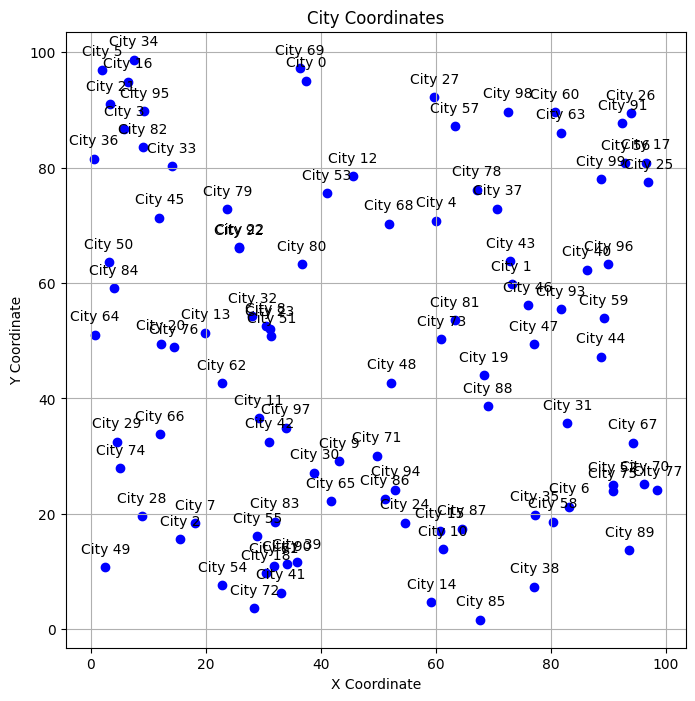

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility

num_cities = 100
cities = {}
for i in range(num_cities):
    cities[i] = (np.random.uniform(0, 100), np.random.uniform(0, 100))

for city_id, coords in cities.items():
    print(f"City {city_id}: {coords}")

plt.figure(figsize=(8, 8))
x_coords = [coord[0] for coord in cities.values()]
y_coords = [coord[1] for coord in cities.values()]
plt.scatter(x_coords, y_coords, color='blue')
for city_id, (x, y) in cities.items():
    plt.annotate(f"City {city_id}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')
plt.title("City Coordinates")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid()
plt.show()


### Distance Calculation

- Implement a function to calculate the Euclidean distance between two cities.
- Implement a function to calculate the total distance of a route (a sequence of cities).

In [3]:
def euclidean_distance(city1, city2):
    return np.sqrt(np.sum((np.array(city1) - np.array(city2)) ** 2))

def total_distance(route, cities):
    distance = 0
    for i in range(len(route)):
        from_city = cities[route[i]]
        to_city = cities[route[(i + 1) % len(route)]]  # Wrap around to the first city
        distance += euclidean_distance(from_city, to_city)
    return distance

## Genetic Algorithm Implementation

### Chromosome Representation

- Chromosome Representation in Detail:
    -  Represent a route (chromosome) as a list of city indices. If we have `n` cities, a chromosome will be a list of `n` unique integers, where each integer corresponds to the index of a city.
    
        For example, if we have cities `A`, `B`, `C`, `D`, and `E`, a chromosome `[2, 0, 3, 1, 4]` means the route is: City C, City A, City D, City B, City E.
    - This representation is suitable for the TSP because it directly encodes the order in which cities are visited, ensuring each city is visited exactly once.
- Implement a function to generate a random initial population of routes.

In [4]:
def initial_population(pop_size, num_cities):
    population = []
    for _ in range(pop_size):
        route = np.random.permutation(num_cities).tolist()
        population.append(route)
    return population

population_size = 5
population = initial_population(population_size, num_cities)
for i, route in enumerate(population):
    print(f"Route {i}: {route}\n\t- Total Distance: {total_distance(route, cities):.2f}")

Route 0: [96, 11, 54, 51, 41, 15, 38, 62, 12, 52, 75, 89, 10, 8, 61, 39, 49, 77, 56, 1, 14, 45, 80, 64, 82, 25, 69, 9, 92, 91, 2, 0, 22, 31, 85, 55, 42, 30, 44, 99, 36, 84, 98, 5, 28, 59, 57, 43, 73, 48, 87, 3, 18, 97, 4, 70, 46, 27, 72, 68, 86, 33, 63, 26, 76, 93, 50, 95, 29, 21, 58, 78, 90, 16, 66, 6, 7, 19, 47, 20, 13, 94, 67, 32, 40, 60, 79, 34, 53, 65, 81, 17, 24, 88, 83, 37, 35, 71, 74, 23]
	- Total Distance: 5069.87
Route 1: [58, 73, 94, 42, 10, 1, 60, 55, 87, 9, 23, 47, 38, 3, 99, 20, 17, 30, 32, 26, 95, 98, 71, 72, 63, 91, 40, 97, 77, 68, 37, 76, 45, 2, 28, 79, 66, 67, 43, 80, 83, 89, 33, 96, 0, 11, 8, 22, 84, 36, 25, 27, 81, 16, 18, 29, 74, 49, 12, 92, 90, 39, 54, 34, 46, 5, 4, 70, 52, 93, 59, 53, 88, 69, 41, 51, 48, 78, 82, 21, 61, 85, 57, 24, 50, 62, 31, 65, 14, 86, 75, 13, 15, 7, 64, 19, 44, 35, 56, 6]
	- Total Distance: 4917.85
Route 2: [30, 77, 5, 76, 14, 96, 98, 13, 51, 4, 67, 29, 81, 47, 56, 38, 54, 58, 59, 55, 26, 99, 75, 21, 93, 19, 27, 16, 71, 2, 48, 74, 69, 97, 37,

### Fitness Function

Implement a fitness function that calculates the inverse of the total route distance
(shorter routes have higher fitness).

In [5]:
def calculate_fitness(route, cities):
    return 1 / total_distance(route, cities)

### Selection

Implement a selection method (e.g., tournament selection or roulette wheel selection) to choose parent routes for crossover.

In [6]:
def tournament_selection(population, fitnesses, tournament_size=3):
    selected_indices = np.random.choice(range(len(population)), tournament_size, replace=False)
    best_index = selected_indices[0]
    for idx in selected_indices[1:]:
        if fitnesses[idx] > fitnesses[best_index]:
            best_index = idx
    return population[best_index]

def roulette_wheel_selection(population, fitnesses):
    total_fitness = sum(fitnesses)
    pick = np.random.uniform(0, total_fitness)
    current = 0
    for i, fitness in enumerate(fitnesses):
        current += fitness
        if current > pick:
            return population[i]

### Crossover

Implement a suitable crossover operator for the TSP (e.g., ordered crossover or partially mapped crossover).

In [7]:
def ordered_crossover(parent1, parent2):
    """
    Performs Ordered Crossover between two parents
    A subrange is copied from the first parent
    and the remaining positions are filled with values from the second parent
    The order of values in the second parent is preserved
    and duplicates are avoided
    
    Args:
        parent1: First parent route
        parent2: Second parent route
        
    Returns:
        Kind-Route
    """
    # Determine random subrange between two indices
    size = len(parent1)
    start, end = sorted(np.random.choice(range(size), 2, replace=False))
    
    # Copy the subrange from the first parent
    child = [-1] * size
    for i in range(start, end + 1):
        child[i] = parent1[i]
    
    # Fill the remaining positions with values from the second parent
    # while preserving the order and avoiding duplicates
    curr_parent2_pos = 0
    for i in range(size):
        if child[i] == -1:  # Position is not yet occupied
            # Find the next value in parent2 that is not yet in child
            while parent2[curr_parent2_pos] in child:
                curr_parent2_pos = (curr_parent2_pos + 1) % size
            child[i] = parent2[curr_parent2_pos]
            curr_parent2_pos = (curr_parent2_pos + 1) % size
    
    return child

### Mutation

Implement a suitable mutation operator for the TSP (e.g., swap mutation or inversion
mutation).

In [8]:
def swap_mutation(route, mutation_rate=0.1):
    if np.random.random() < mutation_rate:
        idx1, idx2 = np.random.choice(len(route), 2, replace=False)
        route[idx1], route[idx2] = route[idx2], route[idx1]
    return route

def inversion_mutation(route, mutation_rate=0.1):
    if np.random.random() < mutation_rate:
        idx1, idx2 = sorted(np.random.choice(len(route), 2, replace=False))
        route[idx1:idx2] = route[idx1:idx2][::-1]
    return route

### Genetic Algorithm Loop

- Implement the main loop of the genetic algorithm, including population initialization,
fitness evaluation, selection, crossover, and mutation.
- Run the algorithm for a specified number of generations and track the best route
found.

In [ ]:
import time
def genetic_algorithm(
        cities,
        population_size=100,
        consecutive_generations=50,
        mutation_method=swap_mutation,
        mutation_rate=0.01,
        elites=5,
        crossover_method=ordered_crossover,
        selection_method=tournament_selection,
        tournament_size=3,
        generations=None
                      ):
    population = initial_population(population_size, len(cities))
    
    best_fitness_history = []
    generation = -1
    while ((generations is None)
        and 
            (len(best_fitness_history) < consecutive_generations or best_fitness_history[-1] != best_fitness_history[-consecutive_generations])
    ) or (generations is not None and generation < generations):
        generation += 1
        fitnesses = [calculate_fitness(route, cities) for route in population]
        
        best_fitness_idx = np.argmax(fitnesses)
        best_fitness_history.append(fitnesses[best_fitness_idx])

        if generation % 50 == 0:
            print(f"Generation {generation}:\n\t- Best Route = {population[best_fitness_idx]}\n\t- Distance = {total_distance(population[best_fitness_idx], cities):.2f}")

        new_population = []

        # Keep elites
        sorted_indices = np.argsort(fitnesses)[-elites:]
        for idx in sorted_indices:
            new_population.append(population[idx])

        # For the rest of the population, perform selection, crossover, and mutation
        while len(new_population) < population_size:
            if selection_method == tournament_selection:
                parent1 = tournament_selection(population, fitnesses, tournament_size)
                parent2 = tournament_selection(population, fitnesses, tournament_size)
            elif selection_method == roulette_wheel_selection:
                parent1 = roulette_wheel_selection(population, fitnesses)
                parent2 = roulette_wheel_selection(population, fitnesses)
            else:
                raise ValueError("Invalid selection method. Choose 'tournament' or 'roulette'.")

            child = crossover_method(parent1, parent2)

            child = mutation_method(child, mutation_rate)
            new_population.append(child)

        population = new_population

    final_fitnesses = [calculate_fitness(route, cities) for route in population]
    best_fitness_idx = np.argmax(final_fitnesses)
    return population[best_fitness_idx], best_fitness_history


start_time = time.time()
best_route, fitness_history = genetic_algorithm(
    cities,
    population_size=300,
    consecutive_generations=300,
    mutation_method=swap_mutation,
    mutation_rate=0.1,
    elites=2,
    crossover_method=ordered_crossover,
    selection_method=tournament_selection,
    tournament_size=3
)
end_time = time.time()
print(f"Best Route: {best_route}\nTotal Distance: {total_distance(best_route, cities):.2f}\nExecution Time: {end_time - start_time:.2f} seconds")
        

Generation 0:
	- Best Route = [96, 95, 89, 56, 93, 44, 77, 62, 90, 15, 13, 85, 26, 66, 25, 45, 14, 88, 59, 32, 6, 58, 76, 2, 74, 79, 36, 84, 3, 53, 80, 83, 68, 75, 39, 20, 27, 0, 50, 19, 29, 28, 63, 17, 64, 86, 46, 40, 99, 91, 12, 35, 31, 70, 60, 49, 1, 61, 22, 4, 10, 38, 9, 72, 30, 98, 43, 51, 67, 52, 54, 55, 94, 69, 81, 78, 8, 11, 92, 34, 21, 65, 7, 97, 33, 16, 5, 71, 57, 23, 47, 42, 37, 41, 24, 73, 48, 82, 87, 18]
	- Distance = 4704.74
Generation 50:
	- Best Route = [84, 74, 20, 71, 24, 79, 53, 45, 34, 16, 3, 95, 92, 22, 57, 27, 82, 33, 12, 47, 81, 90, 29, 28, 66, 80, 68, 4, 62, 42, 48, 97, 86, 46, 93, 35, 41, 55, 14, 87, 94, 30, 31, 44, 25, 91, 77, 38, 70, 99, 17, 43, 1, 52, 6, 19, 11, 13, 49, 76, 50, 60, 56, 96, 39, 65, 10, 67, 88, 15, 58, 98, 51, 23, 5, 21, 32, 2, 61, 83, 18, 54, 9, 8, 73, 59, 75, 89, 85, 72, 7, 37, 78, 63, 26, 40, 0, 69, 36, 64]
	- Distance = 2717.31
Generation 100:
	- Best Route = [84, 79, 45, 34, 16, 3, 95, 92, 22, 82, 33, 57, 27, 53, 12, 47, 81, 48, 55, 41, 9

## Analysis and Visualization

### Performance Analysis

-  Plot the fitness of the best route over generations.
- Discuss how the algorithm’s performance changes with different parameters (population size, crossover/mutation rates).

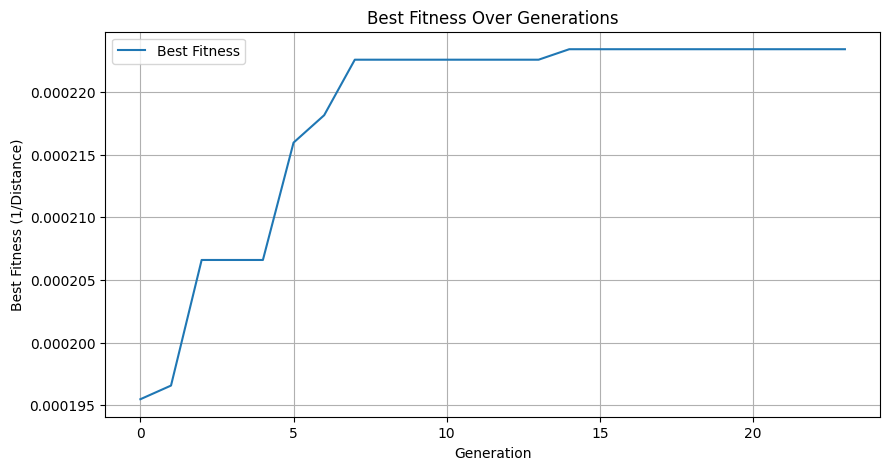

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Best Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (1/Distance)')
plt.legend()
plt.grid()
plt.show()

Starting parameter sensitivity analysis...
Generation 0:
	- Best Route = [94, 88, 49, 53, 86, 14, 35, 96, 19, 85, 43, 25, 79, 59, 12, 99, 76, 71, 91, 60, 18, 33, 21, 4, 47, 89, 78, 55, 58, 52, 42, 64, 66, 61, 30, 36, 95, 17, 38, 83, 56, 26, 31, 57, 9, 67, 40, 23, 51, 98, 48, 84, 45, 92, 24, 32, 3, 13, 10, 65, 80, 97, 82, 28, 1, 11, 90, 46, 15, 50, 81, 68, 39, 41, 5, 34, 75, 73, 7, 62, 27, 54, 16, 93, 74, 63, 20, 69, 0, 22, 8, 29, 72, 2, 6, 77, 87, 37, 44, 70]
	- Distance = 4765.46
Generation 50:
	- Best Route = [31, 52, 35, 54, 5, 74, 94, 68, 0, 3, 16, 64, 20, 42, 24, 15, 58, 89, 38, 14, 10, 67, 44, 7, 29, 71, 23, 81, 99, 40, 98, 48, 32, 92, 97, 47, 93, 65, 30, 55, 49, 28, 39, 12, 78, 25, 57, 96, 59, 75, 18, 41, 61, 2, 62, 66, 90, 88, 73, 22, 95, 13, 76, 82, 80, 53, 4, 79, 27, 60, 91, 26, 17, 46, 1, 43, 37, 87, 85, 84, 33, 21, 34, 36, 50, 9, 72, 83, 11, 51, 19, 56, 63, 45, 69, 86, 8, 77, 70, 6]
	- Distance = 2879.40
Generation 100:
	- Best Route = [31, 52, 35, 54, 5, 74, 94, 68, 0, 3, 

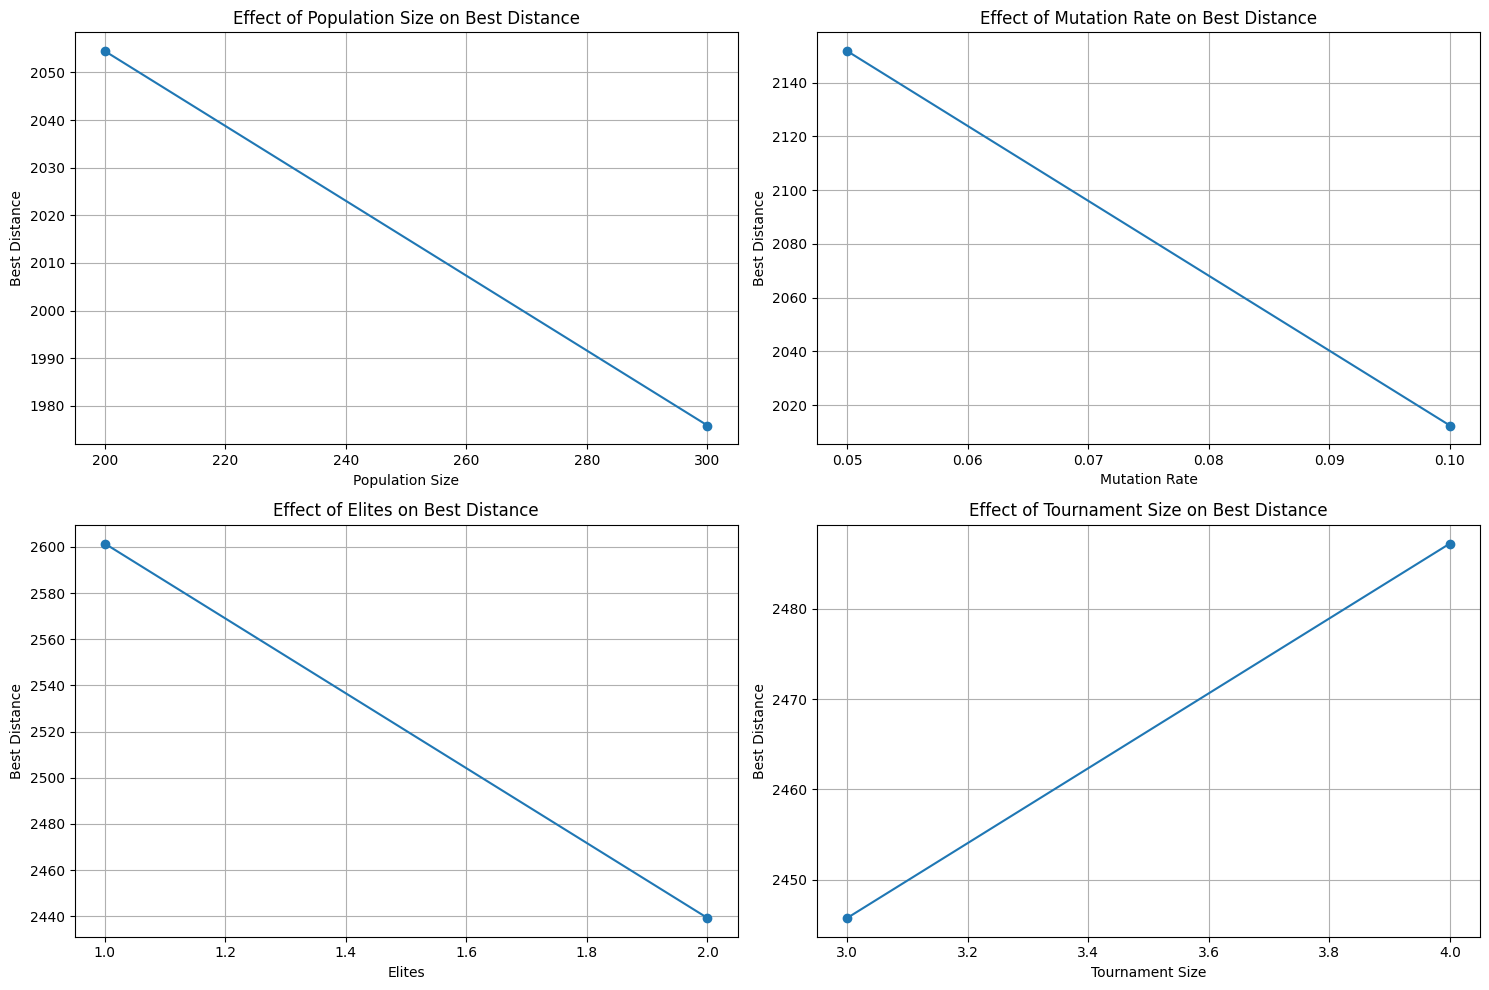

In [19]:
parameters = {
    "Population Size": [200, 300],
    "Mutation Rate": [0.05, 0.1],
    "Elites": [1, 2],
    "Tournament Size": [3, 4]
}

default_params = {
    "Population Size": 100,
    "Generations": 200,
    "Mutation Rate": 0.01,
    "Elites": 2,
    "Tournament Size": 3
}

results = {}
print("Starting parameter sensitivity analysis...")

for param_name, param_values in parameters.items():
    parameter_results = []
    for value in param_values:
        current_params = default_params.copy()
        current_params[param_name] = value
        n_runs = 3
        best_distances = []
        for _ in range(n_runs):
            _, fitness_history = genetic_algorithm(
                cities,
                population_size=current_params["Population Size"],
                generations=current_params["Generations"],
                mutation_method=swap_mutation,
                mutation_rate=current_params["Mutation Rate"],
                elites=current_params["Elites"],
                crossover_method=ordered_crossover,
                selection_method=tournament_selection,
                tournament_size=current_params["Tournament Size"]
            )
            best_distances.append(1 / fitness_history[-1])  # Convert fitness back to distance
        parameter_results.append((value, np.mean(best_distances)))
    
    results[param_name] = parameter_results


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, (param_name, param_results) in enumerate(results.items()):
    values, distances = zip(*param_results)
    axes[i].plot(values, distances, marker='o')
    axes[i].set_title(f'Effect of {param_name} on Best Distance')
    axes[i].set_xlabel(param_name)
    axes[i].set_ylabel('Best Distance')
    axes[i].grid()
plt.tight_layout()
plt.show()


### Route Visualization

- Visualize the best route found by the genetic algorithm on a scatter plot of the cities

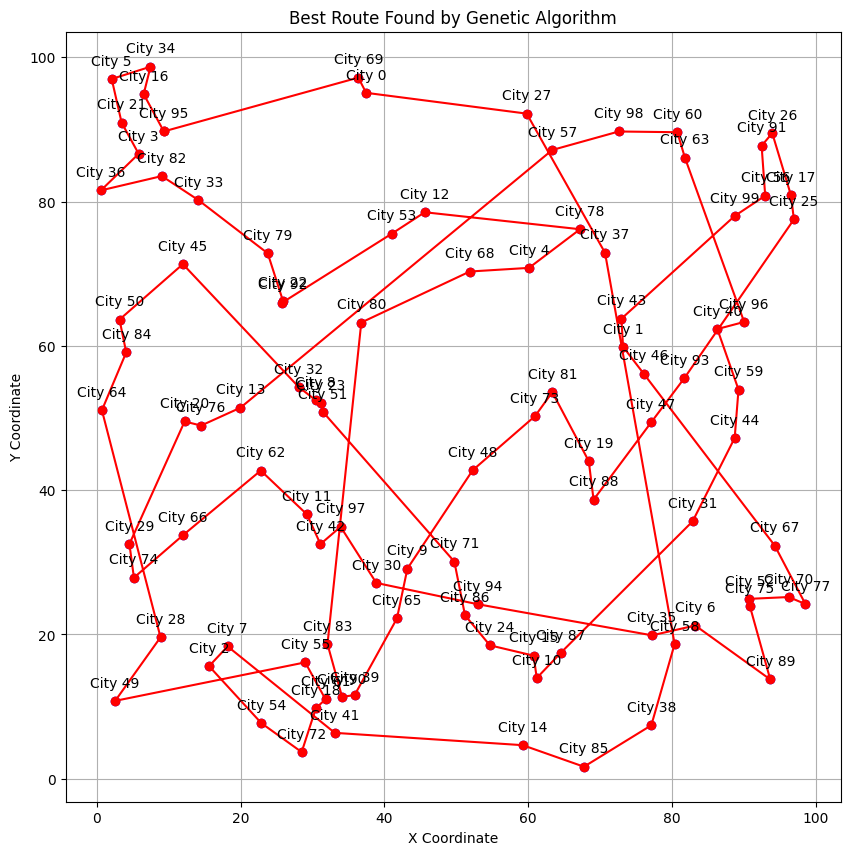

In [21]:
plt.figure(figsize=(10, 10))
for city_id, (x, y) in cities.items():
    plt.scatter(x, y, color='blue')
    plt.annotate(f"City {city_id}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')
route_coords = [cities[city_id] for city_id in best_route]
route_coords.append(cities[best_route[0]])  # Return to the starting city
route_x = [coord[0] for coord in route_coords]
route_y = [coord[1] for coord in route_coords]
plt.plot(route_x, route_y, color='red', marker='o')
plt.title("Best Route Found by Genetic Algorithm")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid()
plt.show()